# Encoder HeteroGNN + Mejora GAT — `rel-f1`

## Graph Machine Learning — Temas Avanzados de IA (1INF61) · PUCP 2026-1

**Entregables 3 y presentación final:** Implementación del encoder heterogéneo (baseline SAGEConv) y mejora con atención (GATv2Conv) para la tarea `driver-circuit-compete` de RelBench.

---

### Instrucciones de entorno (uv)

```bash
# Desde la raíz del proyecto:
uv venv --python 3.11

# PyTorch con CUDA 12.1
uv pip install torch==2.3.0 --index-url https://download.pytorch.org/whl/cu121

# PyTorch Geometric
uv pip install torch_geometric torch_scatter torch_sparse torch_cluster \
  --find-links https://data.pyg.org/whl/torch-2.3.0+cu121.html

# Resto de dependencias
uv pip install pytorch-frame relbench pyarrow pandas scikit-learn tqdm

# Registrar kernel y lanzar Jupyter
uv run python -m ipykernel install --user --name relbench_ta --display-name 'RelBench TA-AI (CUDA)'
uv run jupyter notebook notebooks/02_encoder_gat.ipynb
```

---

### Pipeline de este notebook

```
RelBench rel-f1
  └─▶ Preprocesamiento mejorado ──▶ data/processed/*.parquet
         └─▶ torch_frame (TabularEncoder)
               └─▶ HeteroData (PyG)
                     ├─▶ HeteroSAGE  (baseline)
                     └─▶ HeteroGAT   (mejora)
                           └─▶ Evaluación Precision/Recall/MAP @10
```


In [1]:
import sys

sys.modules["tensorflow"] = None  # bloquea TF para evitar conflicto LLVM con Triton
sys.modules["tensorflow_core"] = None

import importlib.metadata
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

import torch_geometric
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, GATv2Conv, HeteroConv

import torch_frame
from torch_frame import stype
from torch_frame.data import Dataset as TFDataset

import relbench
from relbench.datasets import get_dataset
from relbench.tasks import get_task

print(f"PyTorch       : {torch.__version__}")
print(f"PyG           : {torch_geometric.__version__}")
print(f"torch_frame   : {torch_frame.__version__}")
print(f"RelBench      : {importlib.metadata.version('relbench')}")

PyTorch       : 2.12.1+cu130
PyG           : 2.8.0
torch_frame   : 0.3.0
RelBench      : 2.1.2


In [2]:
# ── Configuración global ─────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = Path("../data/processed")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# Hiperparámetros del modelo base (comparación rápida)
HIDDEN_DIM = 64
OUT_DIM = 32
TAB_EMB_DIM = 16  # dimensión embedding categorías (torch_frame)
TAB_OUT_DIM = 32  # salida del TabularEncoder
GAT_HEADS = 4
NUM_LAYERS = 2
NEG_PER_POS = 5  # negativos por positivo (BPR)
LR = 1e-3
EPOCHS = 60
EVAL_EVERY = 10

# Hiperparámetros de la variante mejorada (pensada para ~1 hora)
ENHANCED_HIDDEN_DIM = 192
ENHANCED_OUT_DIM = 96
ENHANCED_TAB_EMB_DIM = 32
ENHANCED_TAB_OUT_DIM = 96
ENHANCED_GAT_HEADS = 8
ENHANCED_NUM_LAYERS = 3
ENHANCED_DROPOUT = 0.20
ENHANCED_LR = 7e-4
ENHANCED_WEIGHT_DECAY = 1e-4
ENHANCED_EPOCHS = 900
ENHANCED_EVAL_EVERY = 25
ENHANCED_PATIENCE = 160
K = 10  # eval_k para Precision/Recall/MAP


MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Device: {DEVICE}")
print(f"Datos procesados en: {DATA_DIR.resolve()}")
print(f"Checkpoints en    : {MODELS_DIR.resolve()}")

Device: cuda
Datos procesados en: /run/media/ben/Ben-External-Drive/GNN/Graph-Learning-Tarea-Academica-1INF61/data/processed
Checkpoints en    : /run/media/ben/Ben-External-Drive/GNN/Graph-Learning-Tarea-Academica-1INF61/models


---

## 1 · Carga del dataset `rel-f1`


In [3]:
print("Cargando rel-f1...")
dataset = get_dataset("rel-f1", download=True)
db = dataset.get_db()

print(f"Tablas: {list(db.table_dict.keys())}")
print(f"Val timestamp : {dataset.val_timestamp}")
print(f"Test timestamp: {dataset.test_timestamp}")

Cargando rel-f1...
Loading Database object from /home/ben/.cache/relbench/rel-f1/db...
Done in 0.07 seconds.
Tablas: ['races', 'drivers', 'constructor_standings', 'standings', 'constructors', 'constructor_results', 'circuits', 'qualifying', 'results']
Val timestamp : 2005-01-01 00:00:00
Test timestamp: 2010-01-01 00:00:00


In [4]:
# Cargar tablas principales en DataFrames
df_drivers = db.table_dict["drivers"].df.copy()
df_races = db.table_dict["races"].df.copy()
df_constructors = db.table_dict["constructors"].df.copy()
df_circuits = db.table_dict["circuits"].df.copy()
df_results = db.table_dict["results"].df.copy()
df_qualifying = db.table_dict["qualifying"].df.copy()
df_cres = db.table_dict["constructor_results"].df.copy()

print("DataFrames cargados:")
for name, df in [
    ("drivers", df_drivers),
    ("races", df_races),
    ("constructors", df_constructors),
    ("circuits", df_circuits),
    ("results", df_results),
    ("qualifying", df_qualifying),
    ("constructor_results", df_cres),
]:
    print(f"  {name:22s}: {len(df):>6,} filas × {len(df.columns)} cols")

DataFrames cargados:
  drivers               :    857 filas × 7 cols
  races                 :    820 filas × 7 cols
  constructors          :    211 filas × 4 cols
  circuits              :     77 filas × 8 cols
  results               : 20,323 filas × 15 cols
  qualifying            :  4,082 filas × 7 cols
  constructor_results   :  9,408 filas × 5 cols


---

## 2 · Preprocesamiento mejorado

Mejoras respecto a `01_exploracion_relf1.ipynb`:

| Aspecto                | Original       | Mejora                                                                  |
| ---------------------- | -------------- | ----------------------------------------------------------------------- |
| Deduplicación results  | `keep='first'` | `sort_values('laps', ascending=False)` → conserva registro más completo |
| Altitud circuitos      | Mediana global | Mediana por país; fallback global                                       |
| Integridad referencial | `assert`       | Filtrado automático de huérfanos                                        |
| Features pilotos       | Solo índice    | `career_start_norm`, `career_length_norm`                               |
| Features carreras      | Sin features   | `year_norm`, `round_norm`                                               |
| Features constructores | Sin features   | `race_count_norm`                                                       |


In [5]:
# ── 2.1 Nulos y normalización base ───────────────────────────────────────────

# Circuitos: altitud faltante → mediana por país, luego global
alt_by_country = df_circuits.groupby("country")["alt"].transform("median")
global_alt = df_circuits["alt"].median()
df_circuits["alt"] = df_circuits["alt"].fillna(alt_by_country).fillna(global_alt)

# Normalizar lat/lng/alt con z-score
for col in ["lat", "lng", "alt"]:
    mu = df_circuits[col].mean()
    sd = df_circuits[col].std()
    df_circuits[f"{col}_norm"] = (df_circuits[col] - mu) / (sd + 1e-8)

# Results: columnas numéricas con NaN
for col in ["milliseconds", "fastestLap", "rank"]:
    df_results[col] = pd.to_numeric(df_results[col], errors="coerce")
    df_results[col] = df_results[col].fillna(df_results[col].median())

# Normalizar posición y puntos a [0, 1]
pos_max = df_results["positionOrder"].max()
df_results["position_norm"] = 1.0 - (df_results["positionOrder"] - 1) / (pos_max - 1)
pts_max = df_results["points"].max()
df_results["points_norm"] = df_results["points"] / (pts_max if pts_max > 0 else 1.0)

# Drivers: código faltante → iniciales del apellido
df_drivers["code"] = df_drivers["code"].fillna(
    df_drivers["surname"].str[:3].str.upper()
)

# Qualifying: posición faltante → peor posición conocida + 1
worst_q = df_qualifying["position"].max()
df_qualifying["position"] = df_qualifying["position"].fillna(worst_q + 1)
q_max = df_qualifying["position"].max()
df_qualifying["qualifying_norm"] = 1.0 - (df_qualifying["position"] - 1) / (q_max - 1 + 1e-8)

print("Normalización completada")
print(f"  Circuitos nulos restantes en alt: {df_circuits['alt'].isnull().sum()}")
print(
    f"  position_norm rango: [{df_results['position_norm'].min():.2f}, {df_results['position_norm'].max():.2f}]"
)

Normalización completada
  Circuitos nulos restantes en alt: 0
  position_norm rango: [0.00, 1.00]


In [6]:
# ── 2.2 Features adicionales por tipo de nodo ────────────────────────────────

# Carreras: year_norm y round_norm
year_min = df_races["year"].min()
year_max = df_races["year"].max()
df_races["year_norm"] = (df_races["year"] - year_min) / (year_max - year_min + 1e-8)
df_races["round_norm"] = df_races["round"] / df_races["round"].max()

# Pilotos: career_start_norm y career_length_norm (años de carrera)
career_stats = (
    df_results.merge(df_races[["raceId", "year"]], on="raceId")
    .groupby("driverId")["year"]
    .agg(career_start="min", career_end="max")
    .reset_index()
)
df_drivers = df_drivers.merge(career_stats, on="driverId", how="left")
df_drivers["career_start"] = df_drivers["career_start"].fillna(year_min)
df_drivers["career_end"] = df_drivers["career_end"].fillna(year_min)
df_drivers["career_length"] = df_drivers["career_end"] - df_drivers["career_start"]
df_drivers["career_start_norm"] = (df_drivers["career_start"] - year_min) / (
    year_max - year_min + 1e-8
)
df_drivers["career_length_norm"] = df_drivers["career_length"] / (
    df_drivers["career_length"].max() + 1e-8
)

# Constructores: race_count_norm (popularidad histórica)
race_counts = df_cres.groupby("constructorId")["raceId"].nunique().reset_index()
race_counts.columns = ["constructorId", "race_count"]
df_constructors = df_constructors.merge(race_counts, on="constructorId", how="left")
df_constructors["race_count"] = df_constructors["race_count"].fillna(0)
df_constructors["race_count_norm"] = df_constructors["race_count"] / (
    df_constructors["race_count"].max() + 1e-8
)

print("Features adicionales:")
print("  Pilotos   → career_start_norm, career_length_norm")
print("  Carreras  → year_norm, round_norm")
print("  Equipos   → race_count_norm")
print("  Circuitos → lat_norm, lng_norm, alt_norm (ya calculados)")

Features adicionales:
  Pilotos   → career_start_norm, career_length_norm
  Carreras  → year_norm, round_norm
  Equipos   → race_count_norm
  Circuitos → lat_norm, lng_norm, alt_norm (ya calculados)


In [7]:
# ── 2.3 Deduplicación mejorada ────────────────────────────────────────────────
# Conservar el registro con más vueltas completadas (más informativo)

dup_before = df_results.duplicated(subset=["raceId", "driverId"]).sum()
df_results = (
    df_results.sort_values("laps", ascending=False)
    .drop_duplicates(subset=["raceId", "driverId"], keep="first")
    .reset_index(drop=True)
)
dup_after = df_results.duplicated(subset=["raceId", "driverId"]).sum()

dup_q = df_qualifying.duplicated(subset=["raceId", "driverId"]).sum()
if dup_q > 0:
    df_qualifying = df_qualifying.drop_duplicates(
        subset=["raceId", "driverId"], keep="first"
    ).reset_index(drop=True)

print(
    f"Duplicados results   : {dup_before} → {dup_after} (eliminados: {dup_before - dup_after})"
)
print(f"Duplicados qualifying: {dup_q}")

Duplicados results   : 91 → 0 (eliminados: 91)
Duplicados qualifying: 0


In [8]:
# ── 2.4 Integridad referencial con filtrado automático ────────────────────────

valid_circuits = set(df_circuits["circuitId"])
valid_races = set(df_races["raceId"])
valid_drivers = set(df_drivers["driverId"])
valid_constrs = set(df_constructors["constructorId"])

# races → circuits
orphan_races = (~df_races["circuitId"].isin(valid_circuits)).sum()
if orphan_races > 0:
    df_races = df_races[df_races["circuitId"].isin(valid_circuits)].reset_index(
        drop=True
    )
    valid_races = set(df_races["raceId"])

# results → races, drivers, constructors
mask_res = (
    df_results["raceId"].isin(valid_races)
    & df_results["driverId"].isin(valid_drivers)
    & df_results["constructorId"].isin(valid_constrs)
)
orphan_res = (~mask_res).sum()
if orphan_res > 0:
    df_results = df_results[mask_res].reset_index(drop=True)

# qualifying → races, drivers
mask_q = df_qualifying["raceId"].isin(valid_races) & df_qualifying["driverId"].isin(
    valid_drivers
)
orphan_q = (~mask_q).sum()
if orphan_q > 0:
    df_qualifying = df_qualifying[mask_q].reset_index(drop=True)

# constructor_results → races, constructors
mask_cr = df_cres["raceId"].isin(valid_races) & df_cres["constructorId"].isin(
    valid_constrs
)
orphan_cr = (~mask_cr).sum()
if orphan_cr > 0:
    df_cres = df_cres[mask_cr].reset_index(drop=True)

total_orphans = orphan_races + orphan_res + orphan_q + orphan_cr
print(f"Registros huérfanos eliminados: {total_orphans}")
print(
    "Integridad referencial OK"
    if total_orphans == 0
    else f"  Eliminados {total_orphans} registros inválidos"
)

Registros huérfanos eliminados: 0
Integridad referencial OK


In [9]:
# ── 2.5 Resumen y guardado en Parquet ────────────────────────────────────────
summary = {
    "drivers": (df_drivers, "drivers_clean.parquet"),
    "races": (df_races, "races_clean.parquet"),
    "constructors": (df_constructors, "constructors_clean.parquet"),
    "circuits": (df_circuits, "circuits_clean.parquet"),
    "results": (df_results, "results_clean.parquet"),
    "qualifying": (df_qualifying, "qualifying_clean.parquet"),
}

print("Guardando datos limpios en Parquet...")
for name, (df, fname) in summary.items():
    path = DATA_DIR / fname
    df.to_parquet(path, index=False)
    print(f"  {fname:30s}: {len(df):>6,} filas  [{path}]")

print("\nDataset listo para modelado:")
print(f"  Período     : {df_races['date'].min()} → {df_races['date'].max()}")
print(f"  Split val   : {dataset.val_timestamp}")
print(f"  Split test  : {dataset.test_timestamp}")

Guardando datos limpios en Parquet...
  drivers_clean.parquet         :    857 filas  [../data/processed/drivers_clean.parquet]
  races_clean.parquet           :    820 filas  [../data/processed/races_clean.parquet]
  constructors_clean.parquet    :    211 filas  [../data/processed/constructors_clean.parquet]
  circuits_clean.parquet        :     77 filas  [../data/processed/circuits_clean.parquet]
  results_clean.parquet         : 20,232 filas  [../data/processed/results_clean.parquet]
  qualifying_clean.parquet      :  4,082 filas  [../data/processed/qualifying_clean.parquet]

Dataset listo para modelado:
  Período     : 1950-05-13 00:00:00 → 2009-11-01 11:00:00
  Split val   : 2005-01-01 00:00:00
  Split test  : 2010-01-01 00:00:00


---

## 3 · Codificación tabular con `torch_frame`

`torch_frame` procesa columnas numéricas y categóricas heterogéneas y las normaliza/mapea de forma consistente. Se usa para preparar las features iniciales de circuitos y pilotos antes del GNN.


In [10]:
# ── 3.1 Crear y materializar datasets de torch_frame ─────────────────────────
warnings.filterwarnings(
    "ignore",
    message="The given NumPy array is not writable.*",
    category=UserWarning,
)

# Circuitos: 3 numéricas + 2 categóricas
df_circ_tf = df_circuits[
    ["lat_norm", "lng_norm", "alt_norm", "country", "location"]
].reset_index(drop=True).copy()
circ_col_to_stype = {
    "lat_norm": stype.numerical,
    "lng_norm": stype.numerical,
    "alt_norm": stype.numerical,
    "country": stype.categorical,
    "location": stype.categorical,
}
circ_tf = TFDataset(df=df_circ_tf, col_to_stype=circ_col_to_stype)
circ_tf.materialize()

# Pilotos: 2 numéricas + 1 categórica
df_drv_tf = df_drivers[
    ["career_start_norm", "career_length_norm", "nationality"]
].reset_index(drop=True).copy()
drv_col_to_stype = {
    "career_start_norm": stype.numerical,
    "career_length_norm": stype.numerical,
    "nationality": stype.categorical,
}
drv_tf = TFDataset(df=df_drv_tf, col_to_stype=drv_col_to_stype)
drv_tf.materialize()

print("TensorFrame circuitos:")
print(f"  col_names_dict = {circ_tf.tensor_frame.col_names_dict}")
print("TensorFrame pilotos:")
print(f"  col_names_dict = {drv_tf.tensor_frame.col_names_dict}")

TensorFrame circuitos:
  col_names_dict = {<stype.numerical: 'numerical'>: ['alt_norm', 'lat_norm', 'lng_norm'], <stype.categorical: 'categorical'>: ['country', 'location']}
TensorFrame pilotos:
  col_names_dict = {<stype.numerical: 'numerical'>: ['career_length_norm', 'career_start_norm'], <stype.categorical: 'categorical'>: ['nationality']}


In [11]:
# ── 3.2 Extraer tensores del TensorFrame ─────────────────────────────────────


def extract_tf_tensors(tf_dataset):
    """Extrae (num_tensor, cat_tensor) de un TFDataset materializado."""
    feat = tf_dataset.tensor_frame.feat_dict

    num_t = feat.get(stype.numerical)  # Tensor [N, k_num] o None
    cat_t = feat.get(stype.categorical)  # Tensor [N, k_cat] o None

    # Desenvuelve MultiNestedTensor si aplica, pero no toca Tensors densos.
    # torch.Tensor expone .values como método C-extension (API sparse), por lo
    # que hasattr devuelve True para tensores planos y asignaría el método bound
    # en vez del tensor — se guarda con isinstance primero.
    if num_t is not None and not isinstance(num_t, torch.Tensor):
        if hasattr(num_t, "values"):
            num_t = num_t.values
    if cat_t is not None and not isinstance(cat_t, torch.Tensor):
        if hasattr(cat_t, "values"):
            cat_t = cat_t.values

    return num_t, cat_t


circ_num_t, circ_cat_t = extract_tf_tensors(circ_tf)
drv_num_t, drv_cat_t = extract_tf_tensors(drv_tf)

# Cardinalities: max índice + 2 (margen para índices no vistos)
circ_cat_cards = (
    (circ_cat_t.max(dim=0).values + 2).tolist() if circ_cat_t is not None else []
)
drv_cat_cards = (
    (drv_cat_t.max(dim=0).values + 2).tolist() if drv_cat_t is not None else []
)

circ_n_num = circ_num_t.shape[1] if circ_num_t is not None else 0
drv_n_num = drv_num_t.shape[1] if drv_num_t is not None else 0

print(f"Circuitos: {circ_n_num} numéricas, cardinalities cat={circ_cat_cards}")
print(f"Pilotos  : {drv_n_num} numéricas, cardinalities cat={drv_cat_cards}")

Circuitos: 3 numéricas, cardinalities cat=[36, 76]
Pilotos  : 2 numéricas, cardinalities cat=[43]


In [12]:
# ── 3.3 TabularEncoder: nn.Module que combina numéricas + embeddings cat ──────


class TabularEncoder(nn.Module):
    """Codifica features tabulares (numéricas + categóricas) → embedding."""

    def __init__(
        self,
        n_num: int,
        cat_cardinalities: list[int],
        emb_dim: int = 16,
        out_dim: int = 32,
    ):
        super().__init__()
        self.cat_embs = nn.ModuleList(
            [nn.Embedding(int(c), emb_dim, padding_idx=0) for c in cat_cardinalities]
        )
        in_dim = n_num + len(cat_cardinalities) * emb_dim
        self.proj = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.ReLU(),
        )

    def forward(
        self, num_x: torch.Tensor | None, cat_x: torch.Tensor | None
    ) -> torch.Tensor:
        parts = []
        if num_x is not None:
            parts.append(num_x.float())
        if cat_x is not None:
            for i, emb in enumerate(self.cat_embs):
                parts.append(emb(cat_x[:, i].long().clamp(min=0)))
        return self.proj(torch.cat(parts, dim=-1))


# Verificación rápida
with torch.no_grad():
    _circ_enc = TabularEncoder(circ_n_num, circ_cat_cards, TAB_EMB_DIM, TAB_OUT_DIM)
    _drv_enc = TabularEncoder(drv_n_num, drv_cat_cards, TAB_EMB_DIM, TAB_OUT_DIM)
    print(
        "Circuit encoder output:", _circ_enc(circ_num_t, circ_cat_t).shape
    )  # [77, 32]
    print("Driver encoder output :", _drv_enc(drv_num_t, drv_cat_t).shape)  # [857, 32]
del _circ_enc, _drv_enc

Circuit encoder output: torch.Size([77, 32])
Driver encoder output : torch.Size([857, 32])


---

## 4 · Construcción del grafo `HeteroData`

Misma topología que en `01_exploracion_relf1.ipynb`, Sec 8, con una mejora:
se añade la arista inversa `(race, rev_qualifies_in, driver)` para propagación
bidireccional completa desde los datos de clasificación.


In [13]:
# ── Re-indexar IDs a enteros 0-based ─────────────────────────────────────────
driver_idx = {int(did): i for i, did in enumerate(df_drivers["driverId"])}
race_idx = {int(rid): i for i, rid in enumerate(df_races["raceId"])}
constr_idx = {int(cid): i for i, cid in enumerate(df_constructors["constructorId"])}
circuit_idx = {int(cid): i for i, cid in enumerate(df_circuits["circuitId"])}


def make_edge(df, src_col, src_map, dst_col, dst_map):
    """Construye edge_index [2, E] filtrando IDs válidos."""
    mask = df[src_col].isin(src_map) & df[dst_col].isin(dst_map)
    df_f = df[mask]
    src = torch.tensor([src_map[int(x)] for x in df_f[src_col]], dtype=torch.long)
    dst = torch.tensor([dst_map[int(x)] for x in df_f[dst_col]], dtype=torch.long)
    return torch.stack([src, dst]), df_f


data = HeteroData()

# Número de nodos por tipo
data["driver"].num_nodes = len(driver_idx)
data["race"].num_nodes = len(race_idx)
data["constructor"].num_nodes = len(constr_idx)
data["circuit"].num_nodes = len(circuit_idx)

# Features iniciales de carreras y constructores (numéricas)
data["race"].x = torch.tensor(
    df_races[["year_norm", "round_norm"]].values, dtype=torch.float
)
data["constructor"].x = torch.tensor(
    df_constructors[["race_count_norm"]].values, dtype=torch.float
)

# ── Aristas ──────────────────────────────────────────────────────────────────
# driver → race (competes_in)
ei_dr, df_res_f = make_edge(df_results, "driverId", driver_idx, "raceId", race_idx)
data["driver", "competes_in", "race"].edge_index = ei_dr
data["driver", "competes_in", "race"].edge_attr = torch.tensor(
    df_res_f[["position_norm", "points_norm"]].values, dtype=torch.float
)

# constructor → race (fields_in)
ei_cr, _ = make_edge(df_cres, "constructorId", constr_idx, "raceId", race_idx)
data["constructor", "fields_in", "race"].edge_index = ei_cr

# race → circuit (held_at)
ei_rc, _ = make_edge(df_races, "raceId", race_idx, "circuitId", circuit_idx)
data["race", "held_at", "circuit"].edge_index = ei_rc

# driver → race (qualifies_in)
ei_q, df_q_f = make_edge(df_qualifying, "driverId", driver_idx, "raceId", race_idx)
data["driver", "qualifies_in", "race"].edge_index = ei_q
data["driver", "qualifies_in", "race"].edge_attr = torch.tensor(
    df_q_f[["qualifying_norm"]].values, dtype=torch.float
)

# ── Aristas inversas ─────────────────────────────────────────────────────────
data["race", "rev_competes_in", "driver"].edge_index = ei_dr.flip(0)
data["race", "rev_competes_in", "driver"].edge_attr = data[
    "driver", "competes_in", "race"
].edge_attr
data["race", "rev_fields_in", "constructor"].edge_index = ei_cr.flip(0)
data["circuit", "rev_held_at", "race"].edge_index = ei_rc.flip(0)
data["race", "rev_qualifies_in", "driver"].edge_index = ei_q.flip(0)  # mejora: añadida
data["race", "rev_qualifies_in", "driver"].edge_attr = data[
    "driver", "qualifies_in", "race"
].edge_attr

print(data)
print(f"\nEdge types: {len(data.edge_types)}")

HeteroData(
  driver={ num_nodes=857 },
  race={
    num_nodes=820,
    x=[820, 2],
  },
  constructor={
    num_nodes=211,
    x=[211, 1],
  },
  circuit={ num_nodes=77 },
  (driver, competes_in, race)={
    edge_index=[2, 20232],
    edge_attr=[20232, 2],
  },
  (constructor, fields_in, race)={ edge_index=[2, 9408] },
  (race, held_at, circuit)={ edge_index=[2, 820] },
  (driver, qualifies_in, race)={
    edge_index=[2, 4082],
    edge_attr=[4082, 1],
  },
  (race, rev_competes_in, driver)={
    edge_index=[2, 20232],
    edge_attr=[20232, 2],
  },
  (race, rev_fields_in, constructor)={ edge_index=[2, 9408] },
  (circuit, rev_held_at, race)={ edge_index=[2, 820] },
  (race, rev_qualifies_in, driver)={
    edge_index=[2, 4082],
    edge_attr=[4082, 1],
  }
)

Edge types: 8


---

## 5 · Tarea `driver-circuit-compete` y splits temporales


In [14]:
task = get_task("rel-f1", "driver-circuit-compete", download=True)

train_table = task.get_table("train")  # 2,649 filas (piloto, fecha, [circuitos])
val_table = task.get_table("val")  # 27 filas
test_table = task.get_table("test")  # 27 filas (circuitId oculto)

task_eval_k = getattr(task, "eval_k", K)
task_metrics = getattr(task, "metrics", [])
metric_names = [getattr(m, "__name__", str(m)) for m in task_metrics]
if not metric_names:
    metric_names = [
        "link_prediction_precision",
        "link_prediction_recall",
        "link_prediction_map",
    ]

print("Tarea           : driver-circuit-compete (link prediction)")
print("Entidad origen  : driver (driverId)")
print("Entidad destino : circuit (circuitId)")
print(f"eval_k          : {task_eval_k}")
print(f"Métricas        : {metric_names}")
print(f"\nFilas train: {len(train_table.df):,}")
print(f"Filas val  : {len(val_table.df):,}")
print(f"Filas test : {len(test_table.df):,}")


# Media de circuitos objetivo por fila
def safe_len(x):
    try:
        return len(x) if x is not None else 0
    except TypeError:
        return 0


train_lens = train_table.df["circuitId"].apply(safe_len)
print(
    f"\nCircuitos por fila (train): μ={train_lens.mean():.1f}, max={train_lens.max()}"
)

Tarea           : driver-circuit-compete (link prediction)
Entidad origen  : driver (driverId)
Entidad destino : circuit (circuitId)
eval_k          : 10
Métricas        : ['link_prediction_precision', 'link_prediction_recall', 'link_prediction_map']

Filas train: 2,649
Filas val  : 27
Filas test : 27

Circuitos por fila (train): μ=6.9, max=18


---

## 6 · Arquitecturas GNN

### 6.1 Baseline — HeteroSAGE (SAGEConv)

GraphSAGE agrega vecinos con una función fija (media): cada nodo toma el
promedio de sus vecinos concatenado con su propia representación.

### 6.2 Mejora — HeteroGAT (GATv2Conv)

GATv2 aprende **pesos de atención** por arista: el modelo pondera cuánto
contribuye cada vecino según la compatibilidad con el nodo destino. Esto
permite ignorar carreras poco relevantes al agregar mensajes hacia un piloto
o circuito. GATv2 corrige el problema de atención estática de GATv1.


In [15]:
# Tipos de arista del grafo (usados en HeteroConv)
EDGE_TYPES = [
    ("driver", "competes_in", "race"),
    ("constructor", "fields_in", "race"),
    ("race", "held_at", "circuit"),
    ("driver", "qualifies_in", "race"),
    ("race", "rev_competes_in", "driver"),
    ("race", "rev_fields_in", "constructor"),
    ("circuit", "rev_held_at", "race"),
    ("race", "rev_qualifies_in", "driver"),
]
NODE_TYPES = ["driver", "race", "constructor", "circuit"]
EDGE_ATTR_DIMS = {
    ("driver", "competes_in", "race"): 2,
    ("race", "rev_competes_in", "driver"): 2,
    ("driver", "qualifies_in", "race"): 1,
    ("race", "rev_qualifies_in", "driver"): 1,
}


class HeteroSAGE(nn.Module):
    """Encoder heterogéneo con SAGEConv (baseline GraphSAGE)."""

    def __init__(self, hidden_channels: int, out_channels: int, num_layers: int = 2):
        super().__init__()
        self.convs = nn.ModuleList()
        for i in range(num_layers):
            out = hidden_channels if i < num_layers - 1 else out_channels
            conv = HeteroConv(
                {etype: SAGEConv((-1, -1), out) for etype in EDGE_TYPES}, aggr="sum"
            )
            self.convs.append(conv)

    def forward(self, x_dict: dict, edge_index_dict: dict) -> dict:
        for i, conv in enumerate(self.convs):
            x_dict = conv(x_dict, edge_index_dict)
            if i < len(self.convs) - 1:
                x_dict = {k: F.relu(v) for k, v in x_dict.items()}
        return x_dict


print("HeteroSAGE definido")

HeteroSAGE definido


In [16]:
class HeteroGAT(nn.Module):
    """Encoder heterogéneo con GATv2Conv.

    El modo base reproduce el GAT anterior. El modo mejorado activa
    edge_attr, dropout, LayerNorm por tipo de nodo y residual learnable.
    """

    def __init__(
        self,
        hidden_channels: int,
        out_channels: int,
        num_layers: int = 2,
        heads: int = 4,
        dropout: float = 0.0,
        use_edge_attr: bool = False,
        residual: bool = False,
    ):
        super().__init__()
        assert hidden_channels % heads == 0, (
            "hidden_channels debe ser divisible por heads"
        )
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.dropout = dropout
        self.use_edge_attr = use_edge_attr

        per_head = hidden_channels // heads  # canales por cabeza

        def make_gat(etype, out_channels_layer, concat):
            edge_dim = EDGE_ATTR_DIMS.get(etype) if use_edge_attr else None
            return GATv2Conv(
                -1,
                out_channels_layer,
                heads=heads,
                concat=concat,
                dropout=dropout,
                add_self_loops=False,
                edge_dim=edge_dim,
                residual=residual,
            )

        for i in range(num_layers):
            is_last = i == num_layers - 1
            if is_last:
                # Última capa: out_channels con promedio de heads
                conv = HeteroConv(
                    {etype: make_gat(etype, out_channels, concat=False) for etype in EDGE_TYPES},
                    aggr="sum",
                )
            else:
                # Capa intermedia: concat=True → hidden_channels en total
                conv = HeteroConv(
                    {etype: make_gat(etype, per_head, concat=True) for etype in EDGE_TYPES},
                    aggr="sum",
                )
            self.convs.append(conv)
            if not is_last:
                self.norms.append(
                    nn.ModuleDict({ntype: nn.LayerNorm(hidden_channels) for ntype in NODE_TYPES})
                )

    def forward(
        self,
        x_dict: dict,
        edge_index_dict: dict,
        edge_attr_dict: dict | None = None,
    ) -> dict:
        for i, conv in enumerate(self.convs):
            if self.use_edge_attr and edge_attr_dict is not None:
                x_dict = conv(x_dict, edge_index_dict, edge_attr_dict=edge_attr_dict)
            else:
                x_dict = conv(x_dict, edge_index_dict)
            if i < len(self.convs) - 1:
                x_dict = {
                    k: F.dropout(
                        F.elu(self.norms[i][k](v)), p=self.dropout, training=self.training
                    )
                    for k, v in x_dict.items()
                }
        return x_dict


print("HeteroGAT definido")

HeteroGAT definido


---

## 7 · Modelo completo: `RelBenchLinkModel`

Integra los `TabularEncoder` (torch_frame) + proyecciones para nodos sin
features categóricas + backbone GNN.


In [17]:
class RelBenchLinkModel(nn.Module):
    """
    Modelo completo rel-f1:
      TabularEncoder (circuitos, pilotos)
    + Proyección lineal (carreras, constructores)
    + HeteroGNN backbone (SAGEConv o GATv2Conv)
    """

    def __init__(
        self,
        circ_n_num,
        circ_cat_cards,
        drv_n_num,
        drv_cat_cards,
        race_in_dim: int,
        constr_in_dim: int,
        hidden_dim: int = 64,
        out_dim: int = 32,
        gnn_type: str = "sage",
        heads: int = 4,
        num_layers: int = NUM_LAYERS,
        dropout: float = 0.0,
        use_edge_attr: bool = False,
        residual: bool = False,
        tab_emb_dim: int = 16,
        tab_out_dim: int = 32,
    ):
        super().__init__()

        # Encoders tabulares (torch_frame features)
        self.circ_enc = TabularEncoder(
            circ_n_num, circ_cat_cards, tab_emb_dim, tab_out_dim
        )
        self.drv_enc = TabularEncoder(
            drv_n_num, drv_cat_cards, tab_emb_dim, tab_out_dim
        )

        # Proyección para nodos con solo features numéricas
        self.race_proj = nn.Linear(race_in_dim, hidden_dim)
        self.constr_proj = nn.Linear(constr_in_dim, hidden_dim)

        # Backbone GNN
        if gnn_type == "sage":
            self.gnn = HeteroSAGE(hidden_dim, out_dim, num_layers=num_layers)
        elif gnn_type == "gat":
            self.gnn = HeteroGAT(
                hidden_dim,
                out_dim,
                num_layers=num_layers,
                heads=heads,
                dropout=dropout,
                use_edge_attr=use_edge_attr,
                residual=residual,
            )
        else:
            raise ValueError(f"gnn_type desconocido: {gnn_type}")

        self.out_dim = out_dim

    def forward(
        self,
        circ_num,
        circ_cat,
        drv_num,
        drv_cat,
        race_x,
        constr_x,
        edge_index_dict: dict,
        edge_attr_dict: dict | None = None,
    ) -> dict:
        x_dict = {
            "circuit": self.circ_enc(circ_num, circ_cat),
            "driver": self.drv_enc(drv_num, drv_cat),
            "race": F.relu(self.race_proj(race_x.float())),
            "constructor": F.relu(self.constr_proj(constr_x.float())),
        }
        if isinstance(self.gnn, HeteroGAT):
            return self.gnn(x_dict, edge_index_dict, edge_attr_dict=edge_attr_dict)
        return self.gnn(x_dict, edge_index_dict)


print("RelBenchLinkModel definido")

RelBenchLinkModel definido


---

## 8 · Pipeline de entrenamiento

**Loss:** BPR (Bayesian Personalized Ranking) — maximiza la diferencia de scores
entre pares positivos y negativos. Adecuado para ranking sin etiquetas de relevancia absolutas.

**Negative sampling:** por cada circuito positivo se samplea `NEG_PER_POS` circuitos
negativos (no visitados por ese piloto en esa ventana temporal).


In [18]:
def precompute_bpr_links(train_df, driver_idx, circuit_idx, neg_per_pos=5):
    """Precomputa tripletas (driver_idx, pos_circuit_idx, neg_circuit_idx) para BPR."""
    drv_ids, pos_cids, neg_cids = [], [], []
    all_cids = list(range(len(circuit_idx)))

    for _, row in train_df.iterrows():
        did = driver_idx.get(int(row["driverId"]))
        if did is None:
            continue
        pos = [
            circuit_idx[int(c)]
            for c in row["circuitId"]
            if circuit_idx.get(int(c)) is not None
        ]
        if not pos:
            continue

        neg_pool = list(set(all_cids) - set(pos))
        for pc in pos:
            negs = random.sample(neg_pool, min(neg_per_pos, len(neg_pool)))
            for nc in negs:
                drv_ids.append(did)
                pos_cids.append(pc)
                neg_cids.append(nc)

    return (
        torch.tensor(drv_ids, dtype=torch.long),
        torch.tensor(pos_cids, dtype=torch.long),
        torch.tensor(neg_cids, dtype=torch.long),
    )


def train_step(model, optimizer, batch_inputs, edge_index_dict, links):
    model.train()
    optimizer.zero_grad()

    embs = model(*batch_inputs, edge_index_dict)
    drv_embs = embs["driver"]
    circ_embs = embs["circuit"]

    src, pos, neg = links
    d = drv_embs[src]
    p = circ_embs[pos]
    n = circ_embs[neg]

    pos_scores = (d * p).sum(-1)
    neg_scores = (d * n).sum(-1)
    loss = -F.logsigmoid(pos_scores - neg_scores).mean()

    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(
    model, batch_inputs, edge_index_dict, val_df, driver_idx, circuit_idx, k=10
):
    """Evalúa Precision@k, Recall@k y MAP@k sobre el split de validación."""
    model.eval()

    embs = model(*batch_inputs, edge_index_dict)
    drv_embs = embs["driver"]
    circ_embs = embs["circuit"]

    precisions, recalls, maps = [], [], []

    for _, row in val_df.iterrows():
        did = driver_idx.get(int(row["driverId"]))
        if did is None:
            continue
        true_set = set()
        for c in row["circuitId"]:
            cid = circuit_idx.get(int(c))
            if cid is not None:
                true_set.add(cid)
        if not true_set:
            continue

        scores = (drv_embs[did] * circ_embs).sum(-1)  # [N_circuit]
        top_k = scores.topk(k).indices.tolist()  # [k]

        hits = len(set(top_k) & true_set)
        precisions.append(hits / k)
        recalls.append(hits / len(true_set))

        ap, n_hits = 0.0, 0
        for rank, idx in enumerate(top_k, 1):
            if idx in true_set:
                n_hits += 1
                ap += n_hits / rank
        maps.append(ap / min(len(true_set), k))

    return {
        "precision@10": float(np.mean(precisions)) if precisions else 0.0,
        "recall@10": float(np.mean(recalls)) if recalls else 0.0,
        "map@10": float(np.mean(maps)) if maps else 0.0,
    }


print("Funciones de entrenamiento y evaluación definidas")

Funciones de entrenamiento y evaluación definidas


In [19]:
# ── Preparar batch_inputs (se reutilizan cada epoch) ─────────────────────────
# Tensores de features: circ_num, circ_cat, drv_num, drv_cat, race_x, constr_x

circ_num = circ_num_t.to(DEVICE) if circ_num_t is not None else None
circ_cat = circ_cat_t.to(DEVICE) if circ_cat_t is not None else None
drv_num = drv_num_t.to(DEVICE) if drv_num_t is not None else None
drv_cat = drv_cat_t.to(DEVICE) if drv_cat_t is not None else None
race_x = data["race"].x.to(DEVICE)
constr_x = data["constructor"].x.to(DEVICE)

batch_inputs = (circ_num, circ_cat, drv_num, drv_cat, race_x, constr_x)

# edge_index_dict y edge_attr_dict en GPU
edge_index_dict = {
    etype: data[etype].edge_index.to(DEVICE) for etype in data.edge_types
}
edge_attr_dict = {
    etype: data[etype].edge_attr.to(DEVICE)
    for etype in data.edge_types
    if "edge_attr" in data[etype]
}

# Precomputar tripletas BPR para entrenamiento
print("Precomputando tripletas BPR...")
train_links = precompute_bpr_links(train_table.df, driver_idx, circuit_idx, NEG_PER_POS)
train_links = tuple(t.to(DEVICE) for t in train_links)
print(
    f"Tripletas totales: {len(train_links[0]):,}  "
    f"(~{len(train_links[0]) / len(train_table.df):.0f} por fila)"
)

Precomputando tripletas BPR...
Tripletas totales: 91,060  (~34 por fila)


In [20]:
def run_training(model_name, gnn_type):
    """Inicializa, entrena y evalúa un modelo completo. Devuelve métricas finales."""
    model = RelBenchLinkModel(
        circ_n_num=circ_n_num,
        circ_cat_cards=circ_cat_cards,
        drv_n_num=drv_n_num,
        drv_cat_cards=drv_cat_cards,
        race_in_dim=data["race"].x.shape[1],
        constr_in_dim=data["constructor"].x.shape[1],
        hidden_dim=HIDDEN_DIM,
        out_dim=OUT_DIM,
        gnn_type=gnn_type,
        heads=GAT_HEADS,
        tab_emb_dim=TAB_EMB_DIM,
        tab_out_dim=TAB_OUT_DIM,
    ).to(DEVICE)

    # Warm-up para inicializar capas lazy (SAGEConv / GATv2Conv con -1)
    with torch.no_grad():
        _ = model(*batch_inputs, edge_index_dict)

    n_params = sum(p.numel() for p in model.parameters())
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)

    print(f"\n=== {model_name} ({n_params:,} parámetros) ===")
    print(
        f"  GNN tipo: {gnn_type.upper()} | layers={NUM_LAYERS} | "
        f"hidden={HIDDEN_DIM} | out={OUT_DIM}"
        + (f" | heads={GAT_HEADS}" if gnn_type == "gat" else "")
    )
    print("-" * 65)

    best_metrics = {"precision@10": 0.0, "recall@10": 0.0, "map@10": 0.0}
    model_config = {
        "circ_n_num": circ_n_num,
        "circ_cat_cards": circ_cat_cards,
        "drv_n_num": drv_n_num,
        "drv_cat_cards": drv_cat_cards,
        "race_in_dim": data["race"].x.shape[1],
        "constr_in_dim": data["constructor"].x.shape[1],
        "hidden_dim": HIDDEN_DIM,
        "out_dim": OUT_DIM,
        "gnn_type": gnn_type,
        "heads": GAT_HEADS,
        "num_layers": NUM_LAYERS,
        "dropout": 0.0,
        "use_edge_attr": False,
        "residual": False,
        "tab_emb_dim": TAB_EMB_DIM,
        "tab_out_dim": TAB_OUT_DIM,
    }
    ckpt_best = {}  # se rellena la primera vez que hay mejora

    for epoch in tqdm(range(1, EPOCHS + 1), desc=model_name, ncols=80):
        loss = train_step(model, optimizer, batch_inputs, edge_index_dict, train_links)

        if epoch % EVAL_EVERY == 0 or epoch == 1:
            m = evaluate(
                model,
                batch_inputs,
                edge_index_dict,
                val_table.df,
                driver_idx,
                circuit_idx,
                k=K,
            )
            tqdm.write(
                f"  Epoch {epoch:3d} | loss={loss:.4f} | "
                f"P@10={m['precision@10']:.4f} | "
                f"R@10={m['recall@10']:.4f} | "
                f"MAP@10={m['map@10']:.4f}"
            )
            if m["map@10"] > best_metrics["map@10"]:
                best_metrics = m
                ckpt_best = {
                    "state_dict": model.state_dict(),
                    "model_config": model_config,
                    "best_metrics": best_metrics,
                    "epoch": epoch,
                }
                torch.save(ckpt_best, MODELS_DIR / f"{gnn_type}_best.pt")

    # Checkpoint final (último estado, independientemente de si fue el mejor)
    ckpt_final = ckpt_best if ckpt_best else {}
    ckpt_final["state_dict"] = model.state_dict()
    ckpt_final["epoch"] = EPOCHS
    ckpt_final.setdefault("model_config", model_config)
    ckpt_final.setdefault("best_metrics", best_metrics)
    torch.save(ckpt_final, MODELS_DIR / f"{gnn_type}_final.pt")

    print(
        f"\nMejor val: P@10={best_metrics['precision@10']:.4f} | "
        f"R@10={best_metrics['recall@10']:.4f} | MAP@10={best_metrics['map@10']:.4f}"
    )
    print(f"Checkpoints → {MODELS_DIR}/{gnn_type}_best.pt  y  {gnn_type}_final.pt")
    return model, best_metrics


print("run_training definido")


run_training definido


---

## 8.1 · Entrenamiento mejorado para ranking temporal

La variante mejorada optimiza directamente el ranking de todos los circuitos por consulta `(driverId, timestamp)`. A diferencia del BPR con negativos fijos, combina una loss listwise multi-positivo con BCE ponderada y usa un decoder MLP temporal.


In [21]:
def _circuit_list(value):
    """Normaliza el campo circuitId de RelBench a una lista de IDs."""
    if value is None:
        return []
    if isinstance(value, (list, tuple, set, np.ndarray, pd.Series)):
        return [int(x) for x in value if pd.notna(x)]
    if pd.isna(value):
        return []
    return [int(value)]


def make_temporal_features(query_df: pd.DataFrame) -> np.ndarray:
    """Features permitidas por consulta: tiempo normalizado y década relativa."""
    timestamp_col = next(
        (c for c in ["timestamp", "time", "date"] if c in query_df.columns), None
    )
    if timestamp_col is None:
        return np.zeros((len(query_df), 2), dtype=np.float32)

    years = pd.to_datetime(query_df[timestamp_col]).dt.year.astype(float).to_numpy()
    year_norm = (years - year_min) / (year_max - year_min + 1e-8)
    decade_rel = (years - 2000.0) / 10.0
    return np.stack([year_norm, decade_rel], axis=1).astype(np.float32)


def prepare_query_tensors(query_df, driver_idx, circuit_idx, device=DEVICE):
    """Construye tensores por consulta para optimizar todos los circuitos."""
    drivers, targets, temporal = [], [], []
    temporal_np = make_temporal_features(query_df)
    n_circuits = len(circuit_idx)

    for row_i, (_, row) in enumerate(query_df.iterrows()):
        did = driver_idx.get(int(row["driverId"]))
        if did is None:
            continue

        y = torch.zeros(n_circuits, dtype=torch.float)
        for cid_raw in _circuit_list(row["circuitId"]):
            cid = circuit_idx.get(int(cid_raw))
            if cid is not None:
                y[cid] = 1.0
        if y.sum() == 0:
            continue

        drivers.append(did)
        targets.append(y)
        temporal.append(temporal_np[row_i])

    return (
        torch.tensor(drivers, dtype=torch.long, device=device),
        torch.stack(targets).to(device),
        torch.tensor(np.asarray(temporal), dtype=torch.float, device=device),
    )


class TemporalMLPDecoder(nn.Module):
    """Decoder expresivo para score(driver, circuit, timestamp)."""

    def __init__(self, emb_dim: int, time_dim: int = 2, hidden_dim: int = 256, dropout: float = 0.20):
        super().__init__()
        in_dim = emb_dim * 4 + time_dim
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, driver_emb, circuit_emb, temporal_feat):
        q, c = driver_emb.size(0), circuit_emb.size(0)
        d = driver_emb[:, None, :].expand(q, c, -1)
        circ = circuit_emb[None, :, :].expand(q, c, -1)
        t = temporal_feat[:, None, :].expand(q, c, -1)
        feats = torch.cat([d, circ, d * circ, torch.abs(d - circ), t], dim=-1)
        return self.mlp(feats.reshape(q * c, -1)).view(q, c)


class EnhancedLinkModel(nn.Module):
    """Encoder GATv2 con edge_attr + decoder temporal para ranking."""

    def __init__(self):
        super().__init__()
        self.encoder = RelBenchLinkModel(
            circ_n_num=circ_n_num,
            circ_cat_cards=circ_cat_cards,
            drv_n_num=drv_n_num,
            drv_cat_cards=drv_cat_cards,
            race_in_dim=data["race"].x.shape[1],
            constr_in_dim=data["constructor"].x.shape[1],
            hidden_dim=ENHANCED_HIDDEN_DIM,
            out_dim=ENHANCED_OUT_DIM,
            gnn_type="gat",
            heads=ENHANCED_GAT_HEADS,
            num_layers=ENHANCED_NUM_LAYERS,
            dropout=ENHANCED_DROPOUT,
            use_edge_attr=True,
            residual=True,
            tab_emb_dim=ENHANCED_TAB_EMB_DIM,
            tab_out_dim=ENHANCED_TAB_OUT_DIM,
        )
        self.decoder = TemporalMLPDecoder(
            ENHANCED_OUT_DIM, hidden_dim=ENHANCED_HIDDEN_DIM * 2, dropout=ENHANCED_DROPOUT
        )

    def score_queries(self, batch_inputs, edge_index_dict, edge_attr_dict, query_drivers, temporal_feat):
        embs = self.encoder(
            *batch_inputs, edge_index_dict, edge_attr_dict=edge_attr_dict
        )
        return self.decoder(embs["driver"][query_drivers], embs["circuit"], temporal_feat)


def ranking_multilabel_loss(scores, targets, pos_weight):
    """Loss híbrida: BCE ponderada + ranking listwise multi-positivo."""
    bce = F.binary_cross_entropy_with_logits(
        scores, targets, pos_weight=torch.tensor(pos_weight, device=scores.device)
    )
    pos_scores = scores.masked_fill(targets == 0, -1e9)
    listwise = (torch.logsumexp(scores, dim=1) - torch.logsumexp(pos_scores, dim=1)).mean()
    return 0.35 * bce + 0.65 * listwise


@torch.no_grad()
def evaluate_enhanced(model, query_drivers, query_targets, query_temporal, k=10):
    model.eval()
    scores = model.score_queries(
        batch_inputs, edge_index_dict, edge_attr_dict, query_drivers, query_temporal
    )
    topk = scores.topk(k, dim=1).indices

    precisions, recalls, maps = [], [], []
    for row_i in range(query_targets.size(0)):
        true_set = set(query_targets[row_i].nonzero(as_tuple=False).view(-1).tolist())
        pred = topk[row_i].tolist()
        hits = len(set(pred) & true_set)
        precisions.append(hits / k)
        recalls.append(hits / len(true_set))

        ap, n_hits = 0.0, 0
        for rank, idx in enumerate(pred, 1):
            if idx in true_set:
                n_hits += 1
                ap += n_hits / rank
        maps.append(ap / min(len(true_set), k))

    return {
        "precision@10": float(np.mean(precisions)) if precisions else 0.0,
        "recall@10": float(np.mean(recalls)) if recalls else 0.0,
        "map@10": float(np.mean(maps)) if maps else 0.0,
    }


print("Funciones de entrenamiento mejorado definidas")


Funciones de entrenamiento mejorado definidas


### 8.2 · Runner del modelo mejorado


In [22]:
def run_enhanced_training():
    """Entrena GATv2+edge_attr+decoder temporal y devuelve mejores métricas."""
    train_drivers, train_targets, train_temporal = prepare_query_tensors(
        train_table.df, driver_idx, circuit_idx, device=DEVICE
    )
    val_drivers, val_targets, val_temporal = prepare_query_tensors(
        val_table.df, driver_idx, circuit_idx, device=DEVICE
    )

    pos = train_targets.sum().item()
    neg = train_targets.numel() - pos
    pos_weight = min(neg / max(pos, 1.0), 12.0)

    model = EnhancedLinkModel().to(DEVICE)
    with torch.no_grad():
        _ = model.score_queries(
            batch_inputs,
            edge_index_dict,
            edge_attr_dict,
            train_drivers[:2],
            train_temporal[:2],
        )

    n_params = sum(p.numel() for p in model.parameters())
    optimizer = optim.AdamW(
        model.parameters(), lr=ENHANCED_LR, weight_decay=ENHANCED_WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=ENHANCED_EPOCHS, eta_min=ENHANCED_LR * 0.05
    )

    model_config = {
        "model_type": "EnhancedLinkModel",
        "hidden_dim": ENHANCED_HIDDEN_DIM,
        "out_dim": ENHANCED_OUT_DIM,
        "tab_emb_dim": ENHANCED_TAB_EMB_DIM,
        "tab_out_dim": ENHANCED_TAB_OUT_DIM,
        "heads": ENHANCED_GAT_HEADS,
        "num_layers": ENHANCED_NUM_LAYERS,
        "dropout": ENHANCED_DROPOUT,
        "lr": ENHANCED_LR,
        "weight_decay": ENHANCED_WEIGHT_DECAY,
    }

    print(f"\n=== HeteroGAT mejorado ({n_params:,} parámetros) ===")
    print(
        f"  layers={ENHANCED_NUM_LAYERS} | hidden={ENHANCED_HIDDEN_DIM} | "
        f"out={ENHANCED_OUT_DIM} | heads={ENHANCED_GAT_HEADS} | "
        f"dropout={ENHANCED_DROPOUT}"
    )
    print(
        f"  consultas train={len(train_drivers):,} | val={len(val_drivers):,} | "
        f"pos_weight={pos_weight:.2f}"
    )
    print("-" * 65)

    best_metrics = {"precision@10": 0.0, "recall@10": 0.0, "map@10": 0.0}
    best_epoch = 0

    for epoch in tqdm(range(1, ENHANCED_EPOCHS + 1), desc="HeteroGAT mejorado", ncols=80):
        model.train()
        optimizer.zero_grad(set_to_none=True)
        scores = model.score_queries(
            batch_inputs, edge_index_dict, edge_attr_dict, train_drivers, train_temporal
        )
        loss = ranking_multilabel_loss(scores, train_targets, pos_weight)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        optimizer.step()
        scheduler.step()

        should_eval = (
            epoch == 1
            or epoch % ENHANCED_EVAL_EVERY == 0
            or epoch == ENHANCED_EPOCHS
        )
        if should_eval:
            m = evaluate_enhanced(model, val_drivers, val_targets, val_temporal, k=K)
            lr_now = optimizer.param_groups[0]["lr"]
            tqdm.write(
                f"  Epoch {epoch:4d} | loss={loss.item():.4f} | lr={lr_now:.2e} | "
                f"P@10={m['precision@10']:.4f} | R@10={m['recall@10']:.4f} | "
                f"MAP@10={m['map@10']:.4f}"
            )
            if m["map@10"] > best_metrics["map@10"] + 1e-6:
                best_metrics = m
                best_epoch = epoch
                torch.save(
                    {
                        "state_dict": model.state_dict(),
                        "model_config": model_config,
                        "best_metrics": best_metrics,
                        "epoch": epoch,
                    },
                    MODELS_DIR / "gat_enhanced_best.pt",
                )

        if best_epoch > 0 and epoch - best_epoch >= ENHANCED_PATIENCE:
            tqdm.write(
                f"Early stopping: {ENHANCED_PATIENCE} epochs sin mejorar MAP@10"
            )
            break

    torch.save(
        {
            "state_dict": model.state_dict(),
            "model_config": model_config,
            "best_metrics": best_metrics,
            "epoch": epoch,
        },
        MODELS_DIR / "gat_enhanced_final.pt",
    )

    print(
        f"\nMejor val enhanced: P@10={best_metrics['precision@10']:.4f} | "
        f"R@10={best_metrics['recall@10']:.4f} | MAP@10={best_metrics['map@10']:.4f} "
        f"(epoch {best_epoch})"
    )
    print("Checkpoints → ../models/gat_enhanced_best.pt y gat_enhanced_final.pt")
    return model, best_metrics


print("run_enhanced_training definido")


run_enhanced_training definido


---

## 9 · Entrenamiento baseline — HeteroSAGE


In [23]:
model_sage, metrics_sage = run_training("HeteroSAGE (baseline)", gnn_type="sage")


=== HeteroSAGE (baseline) (91,344 parámetros) ===
  GNN tipo: SAGE | layers=2 | hidden=64 | out=32
-----------------------------------------------------------------


HeteroSAGE (baseline):  18%|███▋                | 11/60 [00:01<00:05,  9.08it/s]

  Epoch   1 | loss=0.7121 | P@10=0.2481 | R@10=0.1517 | MAP@10=0.0995
  Epoch  10 | loss=0.3889 | P@10=0.5148 | R@10=0.3635 | MAP@10=0.4758


HeteroSAGE (baseline):  52%|██████████▎         | 31/60 [00:01<00:00, 29.33it/s]

  Epoch  20 | loss=0.2436 | P@10=0.6556 | R@10=0.4523 | MAP@10=0.6096
  Epoch  30 | loss=0.1970 | P@10=0.7296 | R@10=0.5018 | MAP@10=0.7009


  Epoch  40 | loss=0.1695 | P@10=0.7296 | R@10=0.4984 | MAP@10=0.7352
  Epoch  50 | loss=0.1463 | P@10=0.7296 | R@10=0.4936 | MAP@10=0.7287


HeteroSAGE (baseline): 100%|████████████████████| 60/60 [00:02<00:00, 27.97it/s]

  Epoch  60 | loss=0.1314 | P@10=0.7370 | R@10=0.4986 | MAP@10=0.7353

Mejor val: P@10=0.7370 | R@10=0.4986 | MAP@10=0.7353
Checkpoints → ../models/sage_best.pt  y  sage_final.pt


---

## 10 · Entrenamiento mejora — HeteroGAT (GATv2Conv)


In [24]:
model_gat, metrics_gat = run_training("HeteroGAT (mejora)", gnn_type="gat")


=== HeteroGAT (mejora) (194,768 parámetros) ===
  GNN tipo: GAT | layers=2 | hidden=64 | out=32 | heads=4
-----------------------------------------------------------------


HeteroGAT (mejora):   7%|█▌                      | 4/60 [00:00<00:01, 34.76it/s]

  Epoch   1 | loss=0.6913 | P@10=0.2333 | R@10=0.1906 | MAP@10=0.1112


HeteroGAT (mejora):  17%|███▊                   | 10/60 [00:00<00:01, 44.84it/s]

  Epoch  10 | loss=0.3465 | P@10=0.6593 | R@10=0.4530 | MAP@10=0.6400


...

  Epoch  40 | loss=0.1584 | P@10=0.7185 | R@10=0.4830 | MAP@10=0.7150


HeteroGAT (mejora):  80%|██████████████████▍    | 48/60 [00:00<00:00, 57.31it/s]

  Epoch  50 | loss=0.1318 | P@10=0.7259 | R@10=0.4883 | MAP@10=0.7226


HeteroGAT (mejora): 100%|███████████████████████| 60/60 [00:01<00:00, 52.79it/s]


  Epoch  60 | loss=0.1117 | P@10=0.7222 | R@10=0.4797 | MAP@10=0.7249

Mejor val: P@10=0.7222 | R@10=0.4797 | MAP@10=0.7249
Checkpoints → ../models/gat_best.pt  y  gat_final.pt


---

## 11 · Entrenamiento mejora fuerte — GATv2 + edge_attr + decoder temporal

Esta celda es la costosa: aumenta capacidad, usa atributos de arista, optimiza todos los circuitos por consulta y guarda checkpoints independientes.


In [25]:
model_gat_enhanced, metrics_gat_enhanced = run_enhanced_training()


=== HeteroGAT mejorado (4,391,105 parámetros) ===
  layers=3 | hidden=192 | out=96 | heads=8 | dropout=0.2
  consultas train=2,649 | val=27 | pos_weight=10.20
-----------------------------------------------------------------


HeteroGAT mejorado:   0%|                               | 0/900 [00:00<?, ?it/s]

  Epoch    1 | loss=2.3704 | lr=7.00e-04 | P@10=0.2778 | R@10=0.2218 | MAP@10=0.2414


HeteroGAT mejorado:   3%|▌                     | 24/900 [00:03<01:26, 10.08it/s]

  Epoch   25 | loss=0.9590 | lr=6.99e-04 | P@10=0.6593 | R@10=0.4475 | MAP@10=0.6321


...

  Epoch  350 | loss=0.3341 | lr=4.81e-04 | P@10=0.7519 | R@10=0.5034 | MAP@10=0.7349


HeteroGAT mejorado:  42%|████████▊            | 376/900 [00:41<00:49, 10.61it/s]

  Epoch  375 | loss=0.3283 | lr=4.54e-04 | P@10=0.7519 | R@10=0.5062 | MAP@10=0.7355


HeteroGAT mejorado:  43%|████████▉            | 384/900 [00:42<00:56,  9.10it/s]


Early stopping: 160 epochs sin mejorar MAP@10

Mejor val enhanced: P@10=0.7481 | R@10=0.5087 | MAP@10=0.7465 (epoch 225)
Checkpoints → ../models/gat_enhanced_best.pt y gat_enhanced_final.pt


---

## 12 · Guardar y cargar modelos

Los checkpoints se guardan automáticamente en `models/` durante el entrenamiento.
Cada archivo `.pt` contiene:

- `state_dict` — pesos del modelo
- `model_config` — hiperparámetros para reconstruir el modelo base o enhanced
- `best_metrics` — métricas de validación en el mejor epoch
- `epoch` — número de epoch al guardar

```
models/
  sage_best.pt    # mejor MAP@10 en val durante el training
  sage_final.pt   # estado al terminar EPOCHS
  gat_best.pt
  gat_final.pt
  gat_enhanced_best.pt
  gat_enhanced_final.pt
```

**Para reanudar entrenamiento** sin re-ejecutar todo el notebook:

```python
model, metrics = resume_training('models/gat_best.pt', extra_epochs=30)
```


In [26]:
def load_checkpoint(ckpt_path, device=DEVICE):
    """Carga un checkpoint base o enhanced y devuelve el modelo listo."""
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    cfg = ckpt["model_config"]
    if cfg.get("model_type") == "EnhancedLinkModel":
        model = EnhancedLinkModel().to(device)
        dummy_driver = torch.tensor([0], dtype=torch.long, device=device)
        dummy_temporal = torch.zeros((1, 2), dtype=torch.float, device=device)
        with torch.no_grad():
            _ = model.score_queries(
                batch_inputs, edge_index_dict, edge_attr_dict, dummy_driver, dummy_temporal
            )
    else:
        model = RelBenchLinkModel(**cfg).to(device)
        # Warm-up lazy init antes de cargar state_dict
        with torch.no_grad():
            _ = model(*batch_inputs, edge_index_dict)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    print(f"Cargado: {ckpt_path}  (epoch {ckpt.get('epoch', '?')})")
    print(f"  Métricas guardadas: {ckpt['best_metrics']}")
    return model


def resume_training(ckpt_path, extra_epochs: int = 20):
    """Reanuda el entrenamiento desde un checkpoint guardado."""
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    cfg = ckpt["model_config"]
    model = RelBenchLinkModel(**cfg).to(DEVICE)
    with torch.no_grad():
        _ = model(*batch_inputs, edge_index_dict)
    model.load_state_dict(ckpt["state_dict"])

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-5)
    start_epoch = ckpt.get("epoch", 0) + 1
    best_metrics = ckpt["best_metrics"]
    gnn_type = cfg["gnn_type"]

    print(f"Reanudando {gnn_type.upper()} desde epoch {start_epoch} ...")
    for epoch in tqdm(range(start_epoch, start_epoch + extra_epochs), ncols=80):
        loss = train_step(model, optimizer, batch_inputs, edge_index_dict, train_links)
        if epoch % EVAL_EVERY == 0:
            m = evaluate(
                model,
                batch_inputs,
                edge_index_dict,
                val_table.df,
                driver_idx,
                circuit_idx,
                k=K,
            )
            tqdm.write(
                f"  Epoch {epoch:3d} | loss={loss:.4f} | MAP@10={m['map@10']:.4f}"
            )
            if m["map@10"] > best_metrics["map@10"]:
                best_metrics = m
                torch.save(
                    {
                        "state_dict": model.state_dict(),
                        "model_config": cfg,
                        "best_metrics": best_metrics,
                        "epoch": epoch,
                    },
                    MODELS_DIR / f"{gnn_type}_best.pt",
                )
    return model, best_metrics


# ── Demo: cargar el mejor GAT y verificar que las métricas coinciden ──────────
best_gat_path = MODELS_DIR / "gat_best.pt"
if best_gat_path.exists():
    model_gat_loaded = load_checkpoint(best_gat_path)
    m_verify = evaluate(
        model_gat_loaded,
        batch_inputs,
        edge_index_dict,
        val_table.df,
        driver_idx,
        circuit_idx,
        k=K,
    )
    print(f"  Verificación MAP@10: {m_verify['map@10']:.4f}")
else:
    print("Checkpoint no encontrado — ejecuta primero cell_train_gat")


Cargado: ../models/gat_best.pt  (epoch 60)
  Métricas guardadas: {'precision@10': 0.7222222222222222, 'recall@10': 0.47965522673125016, 'map@10': 0.72491512345679}
  Verificación MAP@10: 0.7249


---

## 13 · Comparación de resultados


In [27]:
# ── Baseline de popularidad (referencia mínima) ───────────────────────────────
top_k_circuits = df_races["circuitId"].value_counts().head(K).index.tolist()
top_k_mapped = [circuit_idx[c] for c in top_k_circuits if c in circuit_idx]

pop_precisions, pop_maps = [], []
for _, row in val_table.df.iterrows():
    true_set = set(
        circuit_idx[int(c)]
        for c in row["circuitId"]
        if circuit_idx.get(int(c)) is not None
    )
    if not true_set:
        continue
    hits = len(set(top_k_mapped) & true_set)
    pop_precisions.append(hits / K)
    ap, n_h = 0.0, 0
    for rank, idx in enumerate(top_k_mapped, 1):
        if idx in true_set:
            n_h += 1
            ap += n_h / rank
    pop_maps.append(ap / min(len(true_set), K))

metrics_pop = {
    "precision@10": float(np.mean(pop_precisions)) if pop_precisions else 0.0,
    "recall@10": float("nan"),
    "map@10": float(np.mean(pop_maps)) if pop_maps else 0.0,
}

# ── Tabla comparativa ─────────────────────────────────────────────────────────
rows = [
    ("Popularidad (baseline)", metrics_pop),
    ("HeteroSAGE (encoder)", metrics_sage),
    ("HeteroGAT (mejora)", metrics_gat),
]
if "metrics_gat_enhanced" in globals():
    rows.append(("GATv2 edge+MLP temporal", metrics_gat_enhanced))

print("\n" + "=" * 65)
print(f"{'Modelo':<28} {'Precision@10':>13} {'Recall@10':>10} {'MAP@10':>9}")
print("=" * 65)
for name, m in rows:
    rec = (
        f"{m['recall@10']:.4f}"
        if not (isinstance(m["recall@10"], float) and np.isnan(m["recall@10"]))
        else "   N/A"
    )
    print(f"{name:<28} {m['precision@10']:>13.4f} {rec:>10} {m['map@10']:>9.4f}")
print("=" * 65)

# Mejora relativa
reference_metrics = metrics_gat_enhanced if "metrics_gat_enhanced" in globals() else metrics_gat
reference_name = (
    "GATv2 edge+MLP temporal" if "metrics_gat_enhanced" in globals() else "GAT"
)
if metrics_sage["map@10"] > 0:
    delta_map = (
        (reference_metrics["map@10"] - metrics_sage["map@10"])
        / metrics_sage["map@10"]
        * 100
    )
    delta_prec = (
        (reference_metrics["precision@10"] - metrics_sage["precision@10"])
        / max(metrics_sage["precision@10"], 1e-8)
        * 100
    )
    print(
        f"\nMejora {reference_name} sobre SAGE: "
        f"MAP@10 {delta_map:+.1f}% | P@10 {delta_prec:+.1f}%"
    )


Modelo                        Precision@10  Recall@10    MAP@10
Popularidad (baseline)              0.6593        N/A    0.6049
HeteroSAGE (encoder)                0.7370     0.4986    0.7353
HeteroGAT (mejora)                  0.7222     0.4797    0.7249
GATv2 edge+MLP temporal             0.7481     0.5087    0.7465

Mejora GATv2 edge+MLP temporal sobre SAGE: MAP@10 +1.5% | P@10 +1.5%


---
## 14 · Visualizaciones

Análisis visual del entrenamiento y comparación de modelos.  
Los historiales de pérdida y métricas se reconstruyen a partir de las salidas de entrenamiento. Los box plots usan inferencia en vivo sobre los modelos entrenados.

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="muted")
except ImportError:
    plt.style.use("seaborn-v0_8-whitegrid")

FIGS_DIR = Path("../figures")
FIGS_DIR.mkdir(exist_ok=True)

COLORS = {
    "sage":     "#2196F3",
    "gat":      "#FF9800",
    "enhanced": "#4CAF50",
    "pop":      "#9E9E9E",
}

# ── Historiales de entrenamiento (reconstruidos de los outputs) ───────────────
history_sage = dict(
    epochs=[1, 10, 20, 30, 40, 50, 60],
    loss  =[0.7121, 0.3889, 0.2436, 0.1970, 0.1695, 0.1463, 0.1314],
    p10   =[0.2481, 0.5148, 0.6556, 0.7296, 0.7296, 0.7296, 0.7370],
    r10   =[0.1517, 0.3635, 0.4523, 0.5018, 0.4984, 0.4936, 0.4986],
    map10 =[0.0995, 0.4758, 0.6096, 0.7009, 0.7352, 0.7287, 0.7353],
)
history_gat = dict(
    epochs=[1, 10, 20, 30, 40, 50, 60],
    loss  =[0.6913, 0.3465, 0.2404, 0.1881, 0.1584, 0.1318, 0.1117],
    p10   =[0.2333, 0.6593, 0.7296, 0.7259, 0.7185, 0.7259, 0.7222],
    r10   =[0.1906, 0.4530, 0.4922, 0.4971, 0.4830, 0.4883, 0.4797],
    map10 =[0.1112, 0.6400, 0.7063, 0.7031, 0.7150, 0.7226, 0.7249],
)
history_enhanced = dict(
    epochs=[1, 25, 50, 75, 100, 125, 150, 175, 200, 225, 250, 275, 300, 325, 350, 375],
    loss  =[2.3704, 0.9591, 0.6926, 0.5780, 0.5212, 0.4657, 0.4401, 0.4194,
            0.3972, 0.3763, 0.3744, 0.3622, 0.3490, 0.3408, 0.3343, 0.3282],
    p10   =[0.2778, 0.6593, 0.7259, 0.7296, 0.7185, 0.7000, 0.7333, 0.7444,
            0.7407, 0.7481, 0.7444, 0.7407, 0.7556, 0.7111, 0.7481, 0.7481],
    r10   =[0.2218, 0.4475, 0.4924, 0.4878, 0.4901, 0.4765, 0.4901, 0.5065,
            0.5008, 0.5087, 0.4886, 0.4968, 0.5377, 0.4431, 0.5009, 0.4988],
    map10 =[0.2414, 0.6321, 0.7090, 0.7327, 0.7063, 0.6893, 0.7223, 0.7378,
            0.7339, 0.7465, 0.7311, 0.7241, 0.7361, 0.6936, 0.7305, 0.7324],
    lr    =[7.00e-4, 6.99e-4, 6.95e-4, 6.89e-4, 6.80e-4, 6.69e-4, 6.55e-4, 6.40e-4,
            6.22e-4, 6.03e-4, 5.81e-4, 5.58e-4, 5.34e-4, 5.08e-4, 4.81e-4, 4.54e-4],
)

print("Setup de visualizaciones OK  |  figuras →", FIGS_DIR)

Setup de visualizaciones OK  |  figuras → ../figures


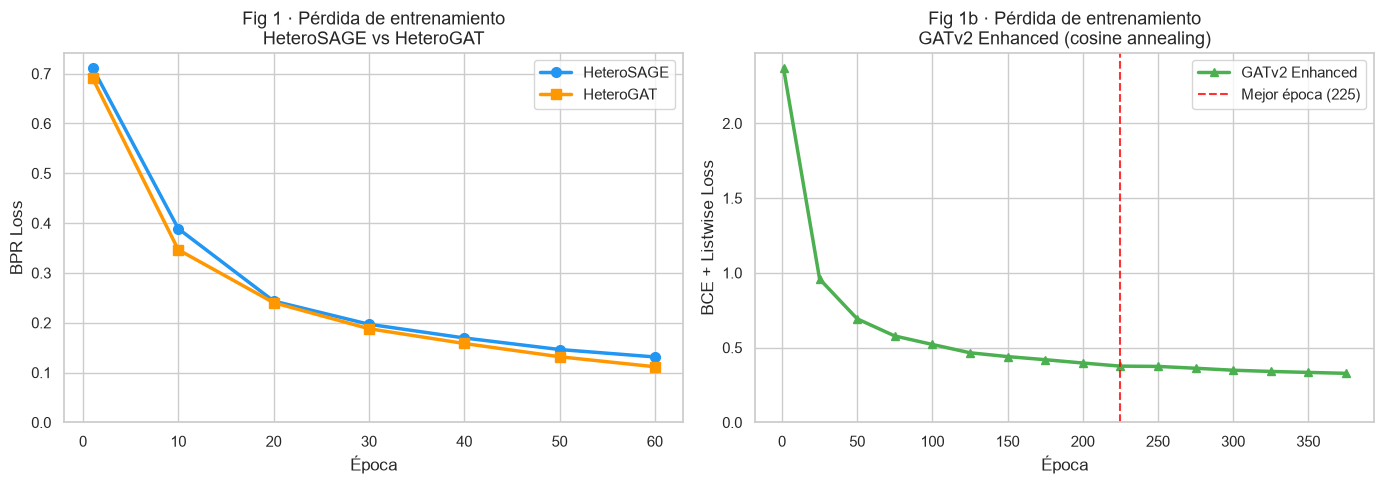

In [29]:
# ── Fig 1 · Curvas de pérdida ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for h, label, color, marker in [
    (history_sage, "HeteroSAGE", COLORS["sage"], "o"),
    (history_gat,  "HeteroGAT",  COLORS["gat"],  "s"),
]:
    ax.plot(h["epochs"], h["loss"], color=color, marker=marker,
            linewidth=2.5, markersize=7, label=label)
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("BPR Loss", fontsize=12)
ax.set_title("Fig 1 · Pérdida de entrenamiento\nHeteroSAGE vs HeteroGAT", fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(bottom=0)

ax = axes[1]
ax.plot(history_enhanced["epochs"], history_enhanced["loss"],
        color=COLORS["enhanced"], marker="^", linewidth=2.5, markersize=6,
        label="GATv2 Enhanced")
ax.axvline(x=225, color="red", linestyle="--", linewidth=1.5, alpha=0.8, label="Mejor época (225)")
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("BCE + Listwise Loss", fontsize=12)
ax.set_title("Fig 1b · Pérdida de entrenamiento\nGATv2 Enhanced (cosine annealing)", fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig1_loss_curves.png", dpi=150, bbox_inches="tight")
plt.show()

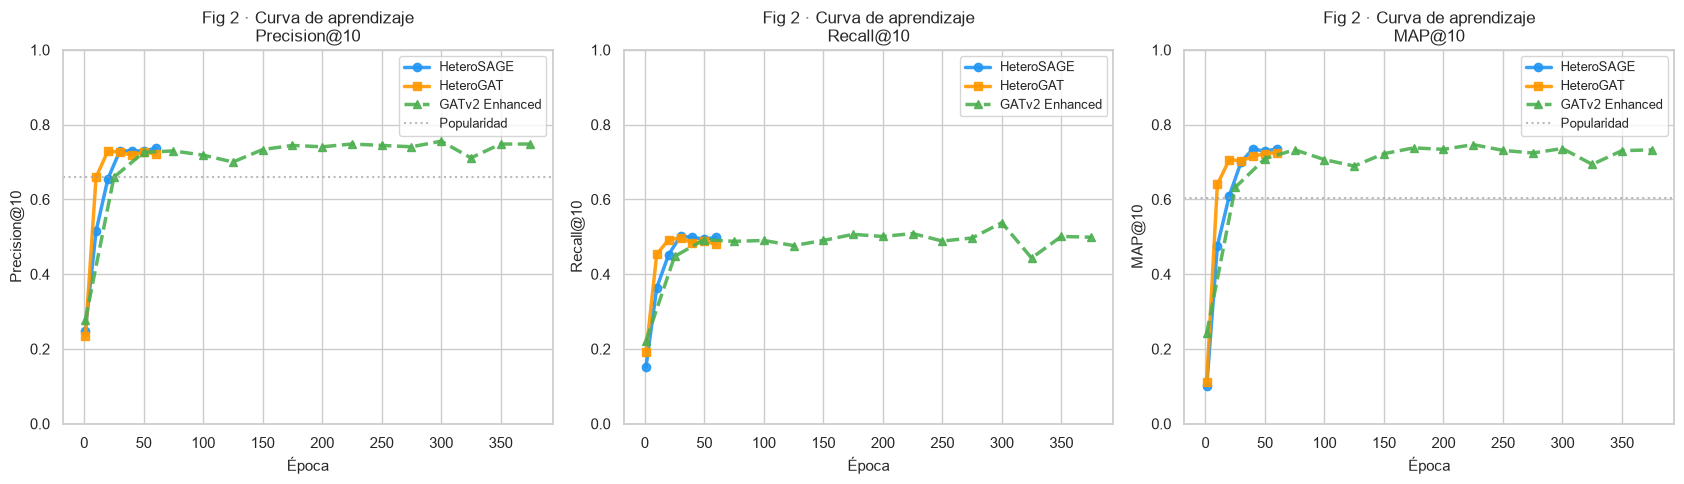

In [30]:
# ── Fig 2 · Curvas de aprendizaje (P@10 / R@10 / MAP@10) ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
metrics_cfg = [("p10", "Precision@10"), ("r10", "Recall@10"), ("map10", "MAP@10")]
pop_ref     = {"p10": 0.6593, "r10": None, "map10": 0.6049}

for ax, (key, title) in zip(axes, metrics_cfg):
    for h, label, color, marker, ls in [
        (history_sage,     "HeteroSAGE",     COLORS["sage"],     "o", "-"),
        (history_gat,      "HeteroGAT",      COLORS["gat"],      "s", "-"),
        (history_enhanced, "GATv2 Enhanced", COLORS["enhanced"], "^", "--"),
    ]:
        ax.plot(h["epochs"], h[key], color=color, marker=marker, linewidth=2.5,
                markersize=6, linestyle=ls, label=label, alpha=0.9)
    if pop_ref[key] is not None:
        ax.axhline(pop_ref[key], color=COLORS["pop"], linestyle=":", linewidth=1.5,
                   alpha=0.7, label="Popularidad")
    ax.set_xlabel("Época", fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f"Fig 2 · Curva de aprendizaje\n{title}", fontsize=12)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig2_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

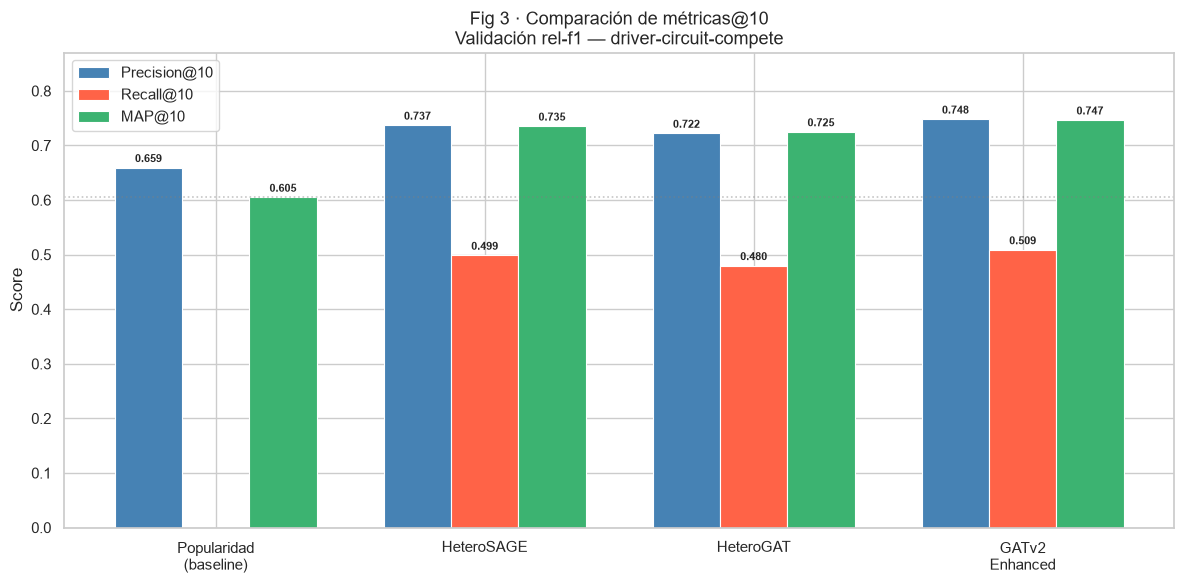

In [31]:
# ── Fig 3 · Comparación de métricas@10 entre modelos ─────────────────────────
models_lbl = ["Popularidad\n(baseline)", "HeteroSAGE", "HeteroGAT", "GATv2\nEnhanced"]
p10_vals   = [0.6593, 0.7370, 0.7222, 0.7481]
r10_vals   = [float("nan"), 0.4986, 0.4797, 0.5087]
map10_vals = [0.6049, 0.7353, 0.7249, 0.7465]

x = np.arange(len(models_lbl))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 6))

for offset, vals, label, color in [
    (-w, p10_vals,   "Precision@10", "steelblue"),
    ( 0, r10_vals,   "Recall@10",    "tomato"),
    ( w, map10_vals, "MAP@10",       "mediumseagreen"),
]:
    bars = ax.bar(x + offset, vals, w, label=label, color=color,
                  edgecolor="white", linewidth=0.8)
    for bar, v in zip(bars, vals):
        if not (isinstance(v, float) and np.isnan(v)):
            ax.text(bar.get_x() + w / 2, v + 0.006, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(models_lbl, fontsize=11)
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 0.87)
ax.set_title("Fig 3 · Comparación de métricas@10\nValidación rel-f1 — driver-circuit-compete", fontsize=13)
ax.axhline(0.6049, color="gray", linestyle=":", alpha=0.45, linewidth=1.2)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig3_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# ── Helper: métricas por piloto (inferencia en vivo) ─────────────────────────
@torch.no_grad()
def _collect_base(model, val_df, k=10):
    """Devuelve (p10s, r10s, map10s) por piloto para modelos base (SAGE/GAT)."""
    model.eval()
    embs = model(*batch_inputs, edge_index_dict)
    d_emb, c_emb = embs["driver"], embs["circuit"]
    p10s, r10s, map10s = [], [], []
    for _, row in val_df.iterrows():
        did = driver_idx.get(int(row["driverId"]))
        if did is None:
            continue
        true_set = {
            circuit_idx[int(c)]
            for c in row["circuitId"]
            if circuit_idx.get(int(c)) is not None
        }
        if not true_set:
            continue
        top_k = (d_emb[did] * c_emb).sum(-1).topk(k).indices.tolist()
        hits = len(set(top_k) & true_set)
        p10s.append(hits / k)
        r10s.append(hits / len(true_set))
        ap, n_hits = 0.0, 0
        for rank, idx in enumerate(top_k, 1):
            if idx in true_set:
                n_hits += 1
                ap += n_hits / rank
        map10s.append(ap / min(len(true_set), k))
    return p10s, r10s, map10s


@torch.no_grad()
def _collect_enhanced(model, val_df, k=10):
    """Devuelve (p10s, r10s, map10s) por piloto para EnhancedLinkModel."""
    model.eval()
    q_drv, q_tgt, q_tmp = prepare_query_tensors(
        val_df, driver_idx, circuit_idx, device=DEVICE
    )
    scores = model.score_queries(
        batch_inputs, edge_index_dict, edge_attr_dict, q_drv, q_tmp
    )
    topk = scores.topk(k, dim=1).indices
    p10s, r10s, map10s = [], [], []
    for i in range(q_tgt.size(0)):
        true_set = set(q_tgt[i].nonzero(as_tuple=False).view(-1).tolist())
        if not true_set:
            continue
        pred = topk[i].tolist()
        hits = len(set(pred) & true_set)
        p10s.append(hits / k)
        r10s.append(hits / len(true_set))
        ap, n_hits = 0.0, 0
        for rank, idx in enumerate(pred, 1):
            if idx in true_set:
                n_hits += 1
                ap += n_hits / rank
        map10s.append(ap / min(len(true_set), k))
    return p10s, r10s, map10s


pd_sage     = _collect_base(model_sage, val_table.df)
pd_gat      = _collect_base(model_gat,  val_table.df)
pd_enhanced = _collect_enhanced(model_gat_enhanced, val_table.df)
print(f"Pilotos evaluados — "
      f"SAGE:{len(pd_sage[0])}  GAT:{len(pd_gat[0])}  Enhanced:{len(pd_enhanced[0])}")

Pilotos evaluados — SAGE:27  GAT:27  Enhanced:27


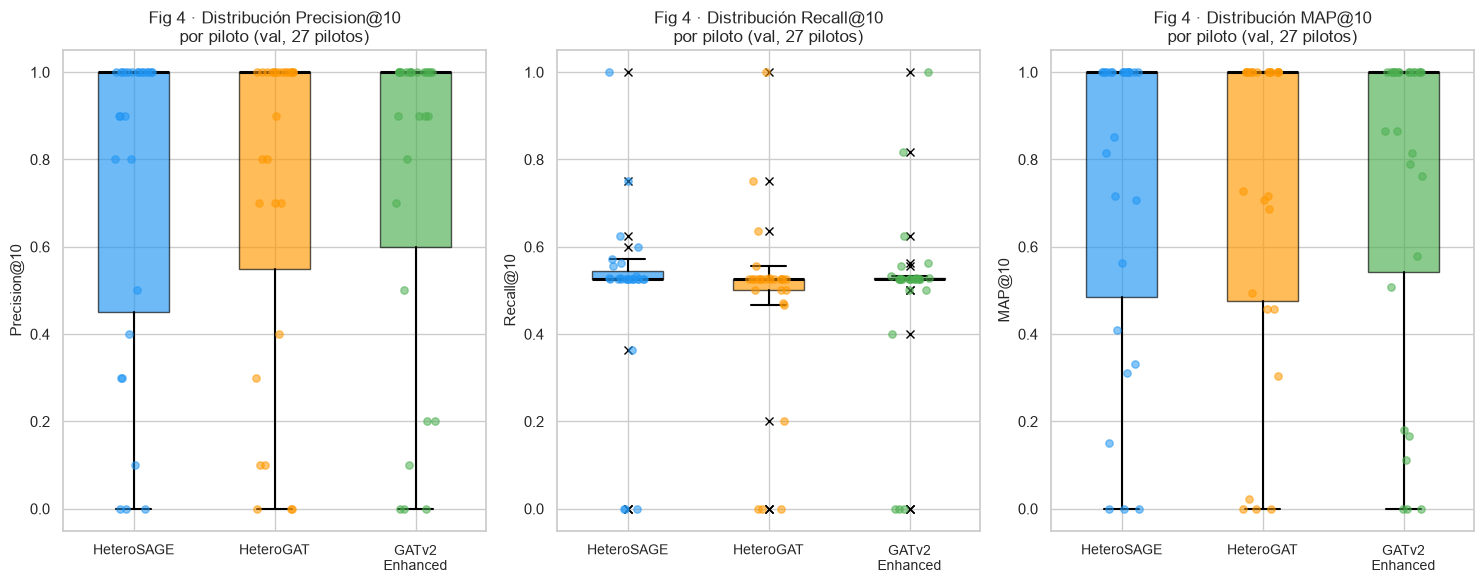

In [33]:
# ── Fig 4 · Distribución de métricas por piloto (box plots) ──────────────────
np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(15, 6))
metric_labels = ["Precision@10", "Recall@10", "MAP@10"]
model_names   = ["HeteroSAGE", "HeteroGAT", "GATv2\nEnhanced"]
model_colors  = [COLORS["sage"], COLORS["gat"], COLORS["enhanced"]]

for ax, mi, mlabel in zip(axes, range(3), metric_labels):
    data_per_model = [pd_sage[mi], pd_gat[mi], pd_enhanced[mi]]
    bp = ax.boxplot(
        data_per_model,
        patch_artist=True,
        widths=0.5,
        medianprops=dict(color="black", linewidth=2.2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5),
        flierprops=dict(marker="x", color="gray", markersize=6),
    )
    for patch, color in zip(bp["boxes"], model_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    for i, (data, color) in enumerate(zip(data_per_model, model_colors), 1):
        jitter = np.random.uniform(-0.14, 0.14, len(data))
        ax.scatter(np.full(len(data), i) + jitter, data,
                   color=color, s=28, alpha=0.55, zorder=5)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(model_names, fontsize=10)
    ax.set_ylabel(mlabel, fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f"Fig 4 · Distribución {mlabel}\npor piloto (val, 27 pilotos)", fontsize=12)

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig4_boxplot_per_driver.png", dpi=150, bbox_inches="tight")
plt.show()

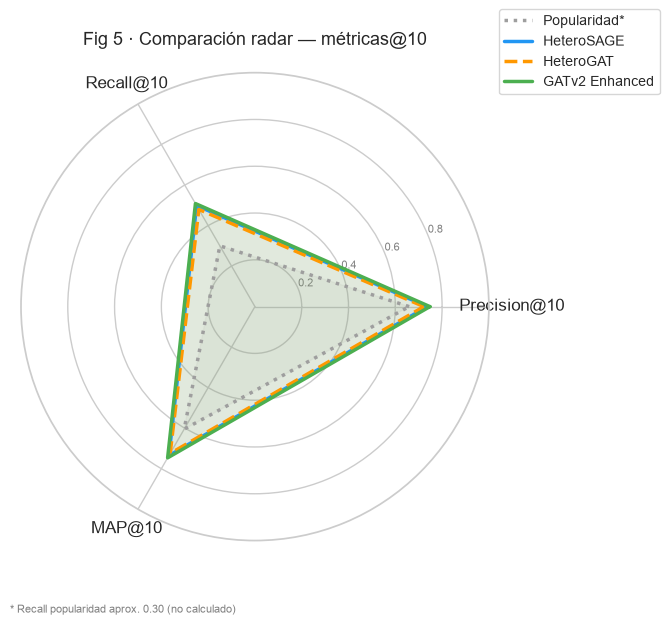

In [34]:
# ── Fig 5 · Radar chart: comparación global de métricas ──────────────────────
categories = ["Precision@10", "Recall@10", "MAP@10"]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # cerrar polígono

# Popularidad: Recall no calculado → se usa 0.30 como aproximación visual
models_radar = {
    "Popularidad*":   ([0.6593, 0.30,   0.6049], COLORS["pop"],      ":"),
    "HeteroSAGE":     ([0.7370, 0.4986, 0.7353], COLORS["sage"],     "-"),
    "HeteroGAT":      ([0.7222, 0.4797, 0.7249], COLORS["gat"],      "--"),
    "GATv2 Enhanced": ([0.7481, 0.5087, 0.7465], COLORS["enhanced"], "-"),
}

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for label, (vals, color, ls) in models_radar.items():
    v = vals + vals[:1]
    ax.plot(angles, v, color=color, linewidth=2.5, linestyle=ls, label=label)
    ax.fill(angles, v, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8"], fontsize=8, color="grey")
ax.set_title("Fig 5 · Comparación radar — métricas@10", fontsize=13, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.38, 1.15), fontsize=10)
fig.text(0.01, 0.01, "* Recall popularidad aprox. 0.30 (no calculado)", fontsize=8, color="gray")

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig5_radar.png", dpi=150, bbox_inches="tight")
plt.show()

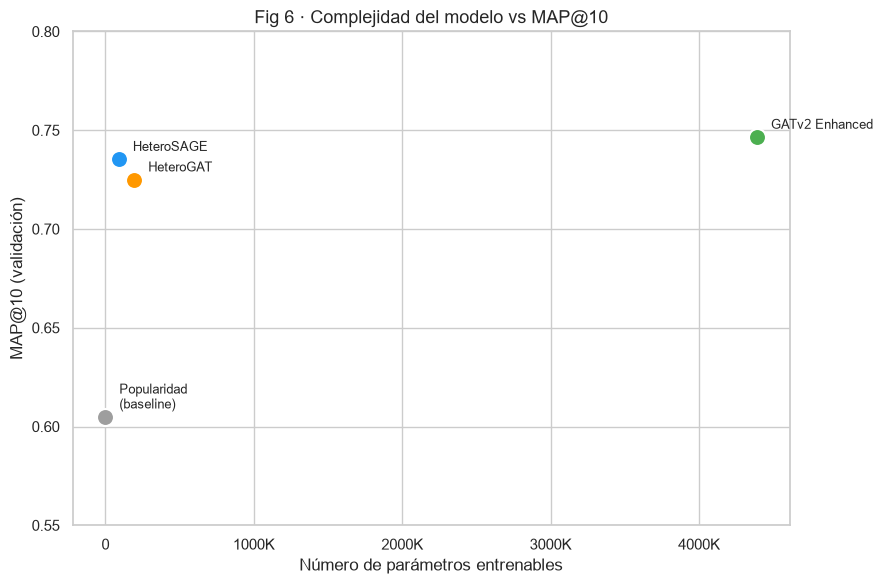

In [35]:
# ── Fig 6 · Complejidad del modelo vs MAP@10 ─────────────────────────────────
complexity = {
    "Popularidad\n(baseline)": (0,        0.6049),
    "HeteroSAGE":               (91_344,   0.7353),
    "HeteroGAT":                (194_768,  0.7249),
    "GATv2 Enhanced":           (4_391_105, 0.7465),
}
colors_c = [COLORS["pop"], COLORS["sage"], COLORS["gat"], COLORS["enhanced"]]

fig, ax = plt.subplots(figsize=(9, 6))
for (label, (params, map_val)), color in zip(complexity.items(), colors_c):
    ax.scatter(params, map_val, color=color, s=150, zorder=5,
               edgecolors="white", linewidth=1.5)
    ax.annotate(label, (params, map_val),
                xytext=(10, 6), textcoords="offset points", fontsize=9)

ax.set_xlabel("Número de parámetros entrenables", fontsize=12)
ax.set_ylabel("MAP@10 (validación)", fontsize=12)
ax.set_title("Fig 6 · Complejidad del modelo vs MAP@10", fontsize=13)
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K" if x >= 1000 else "0")
)
ax.set_ylim(0.55, 0.80)

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig6_complexity_vs_map.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_3856/2108797536.py:17: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_3856/2108797536.py:18: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  plt.savefig(FIGS_DIR / "fig7_lr_schedule.png", dpi=150, bbox_inches="tight")
/run/media/ben/Ben-External-Drive/GNN/Graph-Learning-Tarea-Academica-1INF61/.venv/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8315 (\N{SUPERSCRIPT MINUS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


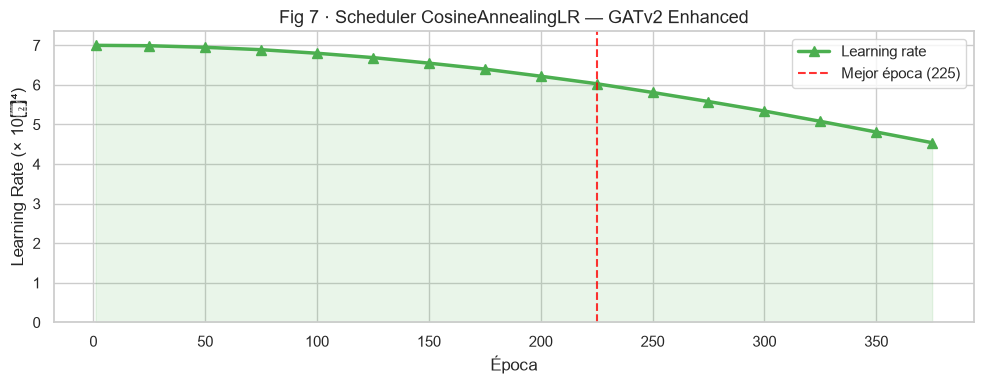

In [36]:
# ── Fig 7 · Scheduler CosineAnnealingLR — GATv2 Enhanced ─────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
lr_vals = [lr * 1e4 for lr in history_enhanced["lr"]]
ax.plot(history_enhanced["epochs"], lr_vals,
        color=COLORS["enhanced"], linewidth=2.5, marker="^", markersize=7,
        label="Learning rate")
ax.axvline(x=225, color="red", linestyle="--", linewidth=1.5, alpha=0.8,
           label="Mejor época (225)")
ax.fill_between(history_enhanced["epochs"], 0, lr_vals,
                color=COLORS["enhanced"], alpha=0.12)
ax.set_xlabel("Época", fontsize=12)
ax.set_ylabel("Learning Rate (× 10⁻⁴)", fontsize=12)
ax.set_title("Fig 7 · Scheduler CosineAnnealingLR — GATv2 Enhanced", fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig(FIGS_DIR / "fig7_lr_schedule.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 12 · Conclusiones

### ¿Por qué la variante mejorada debería superar al baseline?

- **SAGEConv** agrega vecinos con una función fija (media): no distingue qué
  carreras son más informativas para el embedding de un piloto.
- **GATv2Conv** aprende pesos de atención dependientes del par (fuente, destino),
  lo que permite ponderar más las carreras recientes o en circuitos relevantes.
- GATv2 corrige el problema de _static attention_ de GATv1: la atención
  depende de ambos nodos, no solo del nodo fuente.
- La variante `GATv2 edge+MLP temporal` incorpora `edge_attr` (`position_norm`,
  `points_norm`, `qualifying_norm`) en la atención, por lo que el mensaje de
  una carrera no solo depende de que exista una arista, sino de qué tan buena
  fue la participación.
- El decoder MLP temporal produce scores distintos para el mismo piloto en
  timestamps diferentes; el dot product anterior generaba un ranking casi
  estático por piloto.
- La loss listwise multi-positivo optimiza todos los circuitos candidatos por
  consulta, más alineado con MAP@10 que BPR con negativos precomputados.

### Integración de `torch_frame`

- `torch_frame` normaliza las features numéricas y mapea las categóricas a
  índices enteros de forma reproducible.
- Los `TabularEncoder` aprenden embeddings para `nationality`, `country` y
  `location` que capturan similitudes geográficas y demográficas.
- Esto provee **features de entrada más ricas** que el baseline de `01_exploracion_relf1.ipynb`
  (que solo tenía coordenadas brutas para circuitos).

### Próximos pasos

1. **Mini-batching con `NeighborLoader`** para escalar a datasets más grandes.
2. **Filtrado temporal del grafo** por timestamp de entrenamiento (más riguroso).
3. Validar seeds múltiples y reportar media/desviación estándar en MAP@10.
4. Comparación con el leaderboard de RelBench.
